# Visualize Longitudinal stability

Here we use NORDSTAR replication cohort as example.

In [ ]:
from sklearn.neighbors import NearestNeighbors
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.spatial import distance_matrix
from scipy.spatial.distance import pdist, squareform 
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
from scipy.stats import mannwhitneyu
from sklearn.metrics.pairwise import cosine_distances, pairwise_distances
from scipy import stats

k = 50  # define neighbourhood size


df_meta_full = pd.read_csv('Reclustering/Total/Metadata_complete_fu_Nordstar_wClusters.csv', sep='|')
df_meta_rep = df_meta_full[df_meta_full['Replication']==1].reset_index(drop=True).copy()
df_z = pd.read_csv('Reclustering/Total/NORDSTAR_embedding_projections_overTime.csv', sep=',')
lf_col = ['LF0', 'LF1', 'LF2', 'LF3', 'LF4', 'LF5', 'LF6', 'LF7']

df_meta_rep = df_meta_rep.merge(df_z[df_z.columns[1:]][1387:].reset_index(drop=True), left_index=True, right_index=True)
df_meta_rep['visnr'] =df_meta_rep['visnr_x']  
print(len(df_meta_rep['PATNR'].unique()))


df_meta_rep['PATNR'] = df_meta_rep['PATNR'].astype(float)
df_baseline = df_meta_rep[df_meta_rep['visnr_x']==1].copy()
d_clusters_original = dict(zip(df_baseline['PATNR'], df_baseline['PhenoGraph_clusters']))
df_meta_rep['EORA'] = df_meta_rep['Age']<60

df_meta_rep['Original_cluster'] = df_meta_rep['PATNR_x'].apply(lambda x : d_clusters_original[x] if x in d_clusters_original.keys() else np.nan)

df_raw  = df_meta_rep.copy()

#df_raw = df_raw[df_raw['aCCP']==0].copy()

df_meta_full['Original_cluster'] =  df_meta_full['PATNR_x'].apply(lambda x : d_clusters_original[x] if x in d_clusters_original.keys() else np.nan)
df_meta_full['Original_cluster'] = df_meta_full['Original_cluster'].fillna(df_meta_full['PhenoGraph_clusters'])


df_base = df_raw[df_raw["visnr"] == 1].copy().set_index("PATNR")
X_base = df_base[lf_col].values

# fit kNN
n_neighbors = min(k+1, len(df_base))   # +1 includes self
knn = NearestNeighbors(n_neighbors=n_neighbors, metric='cosine')
knn.fit(X_base)

dist_base, neigh_base = knn.kneighbors(X_base)

# remove "self" (first entry)
dist_base = dist_base[:, 1:]
neigh_base = neigh_base[:, 1:]

# mapping
row_to_pid = dict(enumerate(df_base.index))
pid_to_row = {pid: i for i, pid in enumerate(df_base.index)}

# store k-neighbour list per patient
baseline_neighbours = {}

for pid in df_base.index:
    i0 = pid_to_row[pid]
    nbr_ids = [row_to_pid[j] for j in neigh_base[i0]]
    baseline_neighbours[pid] = nbr_ids

results = []

for time in df_raw["visnr"].unique():
    print(time)
    if time in [0, 5.1]:   # skip baseline & special measurement
        continue

    df_visit = df_raw[df_raw["visnr"] == time].copy().set_index("PATNR")

    if len(df_visit) < 2:
        continue

    X_visit = df_visit[lf_col].values
    ids_visit = df_visit.index.values

    # distance matrix for this visit
    D_visit = pairwise_distances(X_visit, metric='cosine')

    # mapping for this visit
    row_visit = {pid: i for i, pid in enumerate(ids_visit)}

    for pid in ids_visit:

        # skip if not present at baseline
        if pid not in baseline_neighbours:
            continue
        
        i = row_visit[pid]
        cluster_i = df_visit.loc[pid, "Original_cluster"] # Original_cluster

        # baseline neighbour list
        base_nbrs = baseline_neighbours[pid]

        # neighbours present at this visit
        nbrs_present = [p for p in base_nbrs if p in row_visit]

        # all non-neighbours at baseline
        non_nbrs_present = [p for p in ids_visit if p not in nbrs_present and p != pid]

        # -------------------
        # Within = distance to baseline neighbours
        # -------------------
        if len(nbrs_present) > 0:
            idx_within = [row_visit[p] for p in nbrs_present]
            dist_within = D_visit[i, idx_within].mean()
        else:
            dist_within = np.nan

        # -------------------
        # Between = distance to baseline NON-neighbours
        # -------------------
        if len(non_nbrs_present) > 0:
            idx_between = [row_visit[p] for p in non_nbrs_present]
            dist_between = D_visit[i, idx_between].mean()
        else:
            dist_between = np.nan

        # -------------------
        # Ratio
        # -------------------
        ss = (
            (dist_between - dist_within) / max(dist_between, dist_within)
            if dist_within > 0 and dist_between > 0
            else np.nan
        )
        
        ratio = (
            dist_between / dist_within 
            if dist_within > 0 and dist_between > 0
            else np.nan
        )
        
        ratio_w = (
            dist_within / dist_between 
            if dist_within > 0 and dist_between > 0
            else np.nan
        )

        results.append({
            "patient_id": pid,
            "Cluster": cluster_i,
            "Time Point": time,
            "Within_distance": dist_within,
            "Between_distance": dist_between,
            "Ratio_between_within": ratio,
            "Ratio_within_between": ratio_w,
            "Silhouette_score": ss,
            "N_within_present": len(nbrs_present),
            "N_between_present": len(non_nbrs_present)
        })

pal_colorblind = ['#4F6CCF', '#2db9cc', '#FBC93D', '#FA4D4D'];
df_stability = pd.DataFrame(results)
df_jips = df_stability.copy()

sns.lineplot(x='Time Point', y='Silhouette_score', hue='Cluster', data=df_stability, marker='o', linewidth=2.5, palette=pal_colorblind)

# Optional: Customize the plot
therapy = 'y'
plt.xticks([1, 2, 3, 4], ["0", "3", "6", "12"], fontsize=14) 
plt.yticks([0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3], fontsize=14)
plt.title("Group Coherence index per JIP in the patient embedding (k=50)", fontsize=14)
plt.xlabel("Time (months)", fontsize=14) 
plt.ylabel('Group coherence index', fontsize=14)  #  (Ratio BCSS vs WCSS)
plt.legend(fontsize=14)
plt.axhline(1, color='gray', linestyle='--', linewidth=3)
plt.ylim([0,0.3])
plt.grid(True)
plt.legend(title='Group', fontsize=9)

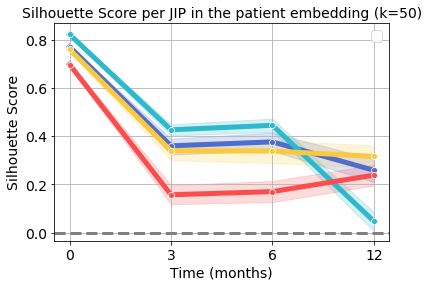

In [6]:
pal_colorblind = ['#4F6CCF', '#2db9cc', '#FBC93D', '#FA4D4D'];
df_stability = pd.DataFrame(results)

#sns.lineplot(data=df_stability, x="Time Point", y="Ratio_between_within", hue="Cluster")
sns.lineplot(x='Time Point', y='Silhouette_score', hue='Cluster', data=df_stability, marker='o', linewidth=5, palette=pal_colorblind)

# Optional: Customize the plot
therapy = 'y'
plt.xticks([1, 2, 3, 4], ["0", "3", "6", "12"], fontsize=14) 
plt.yticks(fontsize=14)
plt.title("Silhouette Score per JIP in the patient embedding (k=50)", fontsize=14)
plt.xlabel("Time (months)", fontsize=14) 
plt.ylabel('Silhouette Score', fontsize=14)  #  (Ratio BCSS vs WCSS)
plt.legend([],fontsize=14)
plt.axhline(0, color='gray', linestyle='--', linewidth=3)
#plt.ylim([-.5,1])
plt.grid(True)

# How much better are our clusters compared to mere chance? 
## conduct 1,000 permutations (random clusterings) to infer significance of our clusters

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import ttest_ind
from scipy.stats import percentileofscore
from scipy.stats import mannwhitneyu

import sys
sys.path.append(r'../src/')
import Functions_temporal as func


# Comparing random scores of Cluster 0 vs Cluster 1
#stat, p_val = mannwhitneyu(dist_cluster_0, dist_cluster_1)
#print(f"Mann-Whitney P-value: {p_val:.5f}")

def t_test(x,y,alternative='both-sided'):
    """
    Description:
        Perform a t-test, either one- or two-sided
    """
    stats, double_p = ttest_ind(list(x),list(y),equal_var = False)

    if alternative == 'both-sided':
        pval = double_p
    elif alternative == 'greater':
        if np.mean(x) > np.mean(y):
            pval = double_p/2.
        else:
            pval = 1.0 - double_p/2.
    elif alternative == 'less':
        if np.mean(x) < np.mean(y):
            pval = double_p/2.
        else:
            pval = 1.0 - double_p/2.
    return stats, pval

def perm_test(x,y):
    # Inside your plotting loop:
    dist = x

    # Non-parametric P-value calculation
    count_better = np.sum(dist >= np.median(y))
    emp_p_val = (count_better + 1) / (len(dist) + 1)

    # Non-parametric Effect Size: Percentile Rank
    # Tells you exactly where your score sits (e.g., 99th percentile)
    
    rank = percentileofscore(dist, actual_val)
    
    return rank, emp_p_val

# --- 3. Run 1000 Random Permutations ---
n_permutations = 1000

results = []

TIME = 4

np.random.seed(777)
cluster_map = df_raw[df_raw['visnr'] == 1].set_index('PATNR')['Original_cluster'].to_dict()


for i in range(n_permutations):
    df_visit = df_raw[df_raw["visnr"] == TIME].copy().set_index('PATNR')
    df_visit['Original_cluster'] = df_visit.index.map(cluster_map)
     # Drop patients who weren't there at baseline or have no cluster
    df_visit = df_visit.dropna(subset=['Original_cluster'])  
    
    df_visit['Original_cluster'] = np.random.randint(1, 5, size=len(df_visit['Original_cluster']))
    
    if len(df_visit) < 2: continue

    # Calculate full distance matrix for the visit
    X_visit = df_visit[lf_col].values
    D_visit = pairwise_distances(X_visit, metric='cosine')
    
    # Get indices for each cluster present at this visit
    cluster_indices = df_visit.groupby('Original_cluster').indices
    
    # Run the manual function
    #individual_ss = one_vs_rest_silhouette(D_visit, df_visit['Original_cluster'].values)
    
    # Run the manual function
    individual_ss, within_distances, between_distances = func.one_vs_rest_silhouette_distances(D_visit, df_visit['Original_cluster'].values)

    # 2. Add these scores back to your visit dataframe so we can group them
    df_visit['patient_ss'] = individual_ss
    df_visit['patient_within'] = within_distances
    df_visit['patient_between'] = between_distances

    # 3. Now, when you iterate through your clusters:
    for cluster_id, member_indices in cluster_indices.items():
        if len(member_indices) < 2: continue
            
        # Get the individual scores for just this cluster
        cluster_scores = df_visit[df_visit['Original_cluster'] == cluster_id]['patient_ss']
        within_scores = df_visit[df_visit['Original_cluster'] == cluster_id]['patient_within']
        between_scores = df_visit[df_visit['Original_cluster'] == cluster_id]['patient_between']
        
        for i in range(len(cluster_scores)):
            results.append({
                "Time Point": time,
                "Cluster": cluster_id,
                "Individual_SS": cluster_scores.iloc[i],  # Raw score per patient
                "Individual_W": within_scores.iloc[i],  # Raw score per patient
                "Individual_B": between_scores.iloc[i],  # Raw score per patient
            })
    




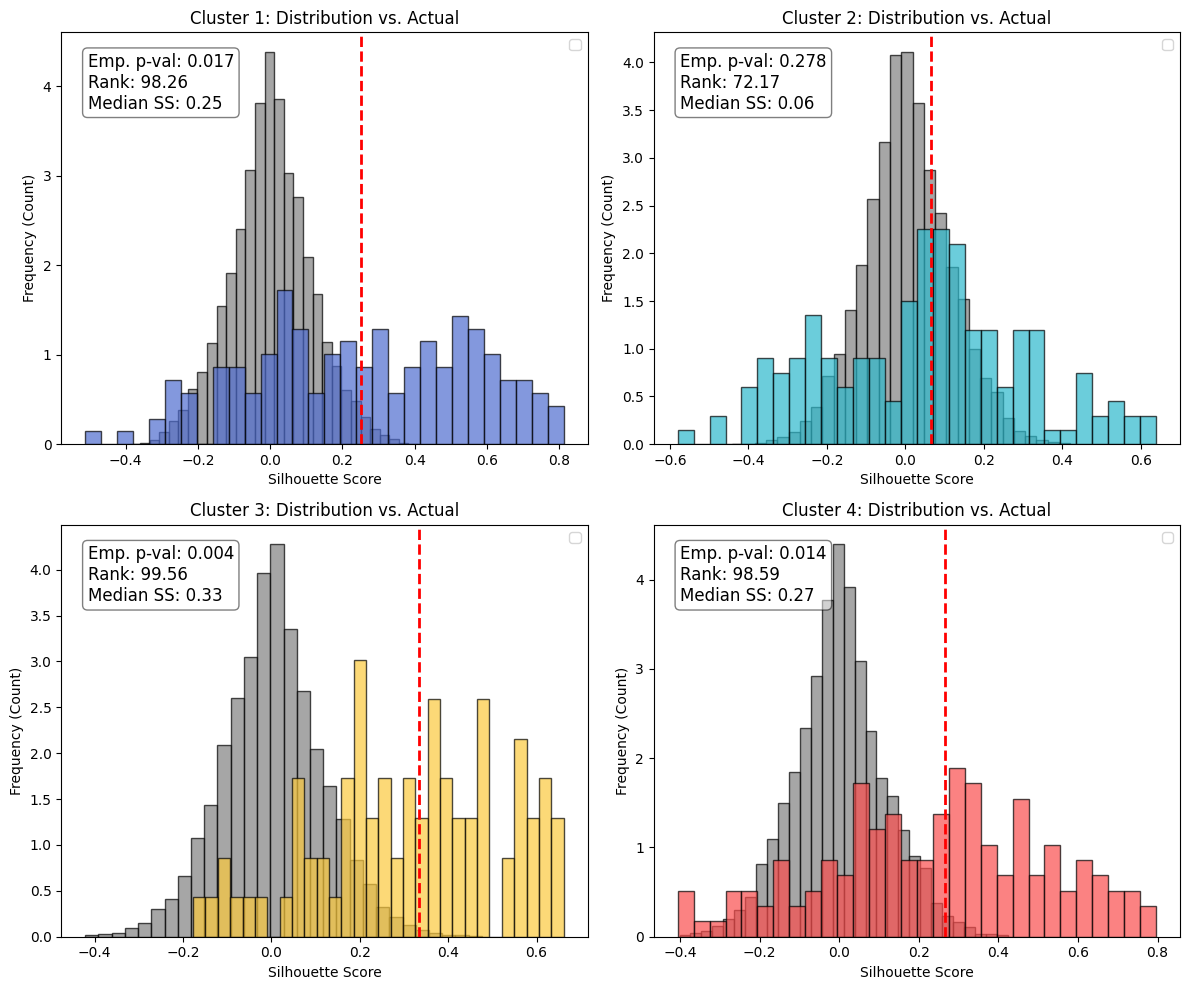

In [18]:
df_stability_perm = pd.DataFrame(results)
df_stability_perm['Ratio_between_within'] = df_stability_perm['Individual_B'] / df_stability_perm['Individual_W']
df_stability_perm['Ratio_within_between'] = df_stability_perm['Individual_W'] / df_stability_perm['Individual_B']

# Now for actual cluster data we only compare last visit 5
df_last_visit = df_jips[df_jips['Time Point']==4].copy()

# Now for actual cluster data we only compare last visit 5
df_last_visit = df_stability[df_stability['Time Point']==4].copy()
df_last_visit = df_last_visit.rename(columns={'Silhouette_score': 'Individual_SS'})
df_last_visit['Cluster'] = df_last_visit['Cluster'] + 1

# Assuming your dataframe is named 'df'
pal_colorblind = ['#4F6CCF', '#2db9cc', '#FBC93D', '#FA4D4D'];

clusters = df_stability_perm['Cluster'].unique()

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, cluster_id in enumerate(clusters):
    # Filter for the specific cluster permutations
    cluster_data_perm = df_stability_perm[df_stability_perm['Cluster'] == cluster_id]
    cluster_data = df_last_visit[(df_last_visit['Cluster'] == cluster_id)].copy()
    
    # 1. Plot the histogram of random permutation scores
    axes[int(cluster_id)-1].hist(cluster_data_perm['Individual_SS'], bins=30, 
                 color='gray', edgecolor='black', alpha=0.7, 
                 label='Random Permutations', density=True)
    axes[int(cluster_id)-1].hist(cluster_data['Individual_SS'], bins=30, 
                 color=pal_colorblind[int(cluster_id)-1], edgecolor='black', alpha=0.7, 
                 label='Actual cluster', density=True)
    
    # Get mean reference ss
    actual_val = cluster_data['Individual_SS'].median()
    
    
    # 2. Add the reference SS line for the actual cluster
    #actual_val = reference_ss_list[i]
    axes[int(cluster_id)-1].axvline(actual_val, color='red', linestyle='--', linewidth=2, 
                    label=f'Actual SS: {actual_val:.3f}')
    
    # Formatting
    axes[int(cluster_id)-1].set_title(f'Cluster {cluster_id}: Distribution vs. Actual')
    axes[int(cluster_id)-1].set_xlabel('Silhouette Score')
    axes[int(cluster_id)-1].set_ylabel('Frequency (Count)')
    axes[int(cluster_id)-1].legend([])
    
    # Perform one tailed t-test
    #tstat, pval = t_test(cluster_data['Individual_SS'], cluster_data_perm['Individual_SS'], alternative='greater')
    tstat, pval = perm_test(cluster_data_perm['Individual_SS'], cluster_data['Individual_SS'])
   
    # --- ANNOTATION BLOCK ---
    # We use transform=ax.transAxes so (0,0) is bottom-left and (1,1) is top-right
    text_str = f'Emp. p-val: {pval:.3f}\nRank: {tstat:.2f}\nMedian SS: {actual_val:.2f}'

    axes[int(cluster_id)-1].text(0.05, 0.95, text_str, 
            transform=axes[int(cluster_id)-1].transAxes, 
            fontsize=12,
            verticalalignment='top', 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
    # -------------------------

plt.tight_layout()
plt.show()

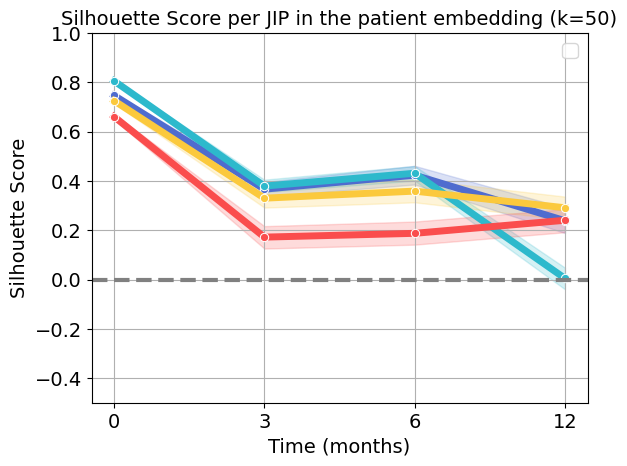

In [376]:
pal_colorblind = ['#4F6CCF', '#2db9cc', '#FBC93D', '#FA4D4D'];
df_stability = pd.DataFrame(results)

#sns.lineplot(data=df_stability, x="Time Point", y="Ratio_between_within", hue="Cluster")
sns.lineplot(x='Time Point', y='Silhoette_score', hue='Cluster', data=df_stability, marker='o', linewidth=5, palette=pal_colorblind)

# Optional: Customize the plot
therapy = 'y'
plt.xticks([1, 2, 3, 4], ["0", "3", "6", "12"], fontsize=14) 
plt.yticks(fontsize=14)
plt.title("Silhouette Score per JIP in the patient embedding (k=50)", fontsize=14)
plt.xlabel("Time (months)", fontsize=14) 
plt.ylabel('Silhouette Score', fontsize=14)  #  (Ratio BCSS vs WCSS)
plt.legend([],fontsize=14)
plt.axhline(0, color='gray', linestyle='--', linewidth=3)
plt.ylim([-.5,1])
plt.grid(True)

## Visualize trajectory of patients on 2d umap

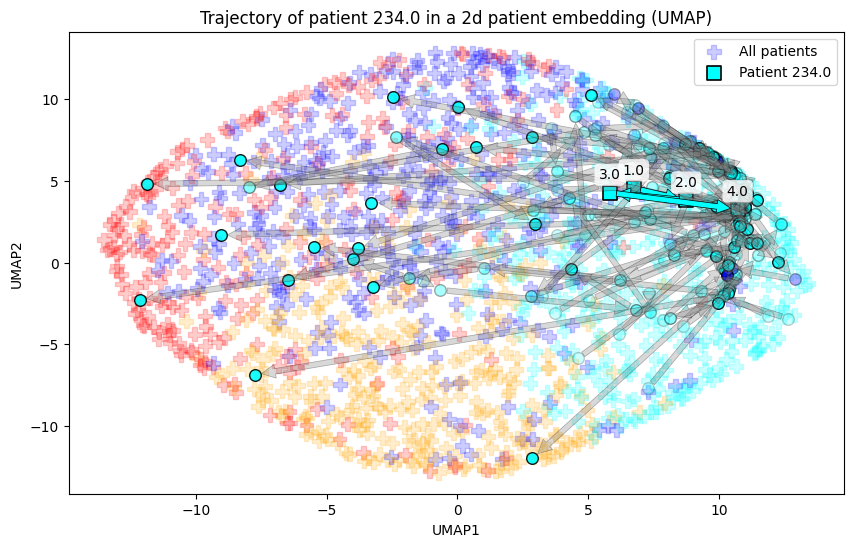

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ANNOTATE = True
PLOT_ARROW = True
PLOT_ARROW_PATIENT = True
COLOR_BG = True
COLOR_CLUSTER = True

# Select the patient to highlight
selected_patient_id = 234.0 #'226.0' # 5302 #'3021'#'3309'


#embedder = load_ParametricUMAP('/exports/reum/tdmaarseveen/RA_Clustering/notebooks/models/umap/umap_mapping_NORDSTAR_two')
#X_embedded = embedder.transform(df_z[df_z.columns[1:]].values)

# Sample data: assume df contains PCA components, patient IDs, and visit dates
data_plot = {
    'patient_id': df_meta_full['PATNR'].astype(str),
    'visit_date': df_meta_full['visnr_x'].fillna(0),
    'cluster': df_meta_full['Original_cluster'],
    'PCA1': X_embedded[:,0],
    'PCA2': X_embedded[:,1]
}
df_plot = pd.DataFrame(data_plot)



# Get neighbours
l_neighbours = baseline_neighbours[selected_patient_id]#[:2]

# Filter and sort the data for the selected patient
patient_data = df_plot[df_plot['patient_id'] == str(selected_patient_id)].sort_values(by='visit_date')

# Plot all PCA points

# Map the cluster values to their corresponding colors
if COLOR_CLUSTER:
    d_cluscol = {3.0 : 'red', 2.0 : 'orange',1.0 : 'cyan', 0.0 :'blue'}
else :
    d_cluscol = {3.0 : 'blue', 2.0 : 'blue',1.0 : 'blue', 0.0 :'blue'}
colors = df_plot[:1387]['cluster'].map(d_cluscol)
colors_bg = df_plot[:1387]['cluster'].map({3.0 : 'red', 2.0 : 'orange',1.0 : 'cyan', 0.0 :'blue'})

plt.figure(figsize=(10, 6))
if COLOR_BG:
    plt.scatter(df_plot[:1387]['PCA1'], df_plot[:1387]['PCA2'], c=colors_bg, label='All patients', s=100, alpha=0.2, marker='P')
else :
    plt.scatter(df_plot[:1387]['PCA1'], df_plot[:1387]['PCA2'], c='lightgrey', label='All patients')
d_color = {1.0 : 'red', 2.0 : 'orange', 3.0 : 'yellow', 4.0 :'cyan', 5.0 : 'green'}

for pid in l_neighbours:
    neighbour_data = df_plot[df_plot['patient_id'] == str(pid)].sort_values(by='visit_date')
    x = neighbour_data['PCA1'].values
    y = neighbour_data['PCA2'].values
    
    
    #plt.scatter(neighbour_data['PCA1'], neighbour_data['PCA2'], c=colors, label=f'Patient {pid}')
    
    # 1. Normalize visit dates to a 0.2 - 1.0 range for alpha
    # This ensures the first visit isn't completely invisible (0.0)
    v_min, v_max = neighbour_data['visit_date'].min(), neighbour_data['visit_date'].max()
    
    # If there's only one visit, set alpha to 1.0; otherwise, scale it
    if v_max == v_min:
        alphas = pd.Series([0.8] * len(neighbour_data))
    else:
        alphas = 0.2 + 0.4 * (neighbour_data['visit_date'] - v_min) / (v_max - v_min)
    #print(alphas)
    if len(alphas) > 0:
        alphas.iloc[-1] = 0.9 # ensure last item is always 1 (not larger)

    # 2. Plotting the points with varying opacity
    # Note: plt.scatter 'c' can be a single color, but 'alpha' must be applied
    # specifically if you want it to vary per point. 
    # The easiest way is to use a RGBA color array:
    for i in range(len(x)):
        plt.scatter(x[i], y[i], color=d_cluscol[neighbour_data['cluster'].iloc[0]], alpha=alphas.iloc[i], s=70, edgecolors='black',)
    
    #plt.plot(neighbour_data['PCA1'], neighbour_data['PCA2'], c='grey', linestyle='--')
    if PLOT_ARROW:
        for i in range(len(x) - 1):
            plt.annotate('', 
                         xy=(x[i+1], y[i+1]),      # Tip of the arrow
                         xytext=(x[i], y[i]),      # Tail of the arrow
                         arrowprops=dict(
                             arrowstyle='simple',
                             #linestyle='--',       # Your requested dashed style
                             facecolor='grey',
                             edgecolor='black',         # Neutral color so point colors pop
                             linewidth=0.5,
                             #alpha=0.7,
                             alpha=0.3,
                             mutation_scale=20,     # Controls the size of the arrow head
                             shrinkA=5,             # Small gap from start point
                             shrinkB=5,           # Small gap from end point
                             #alpha=alphas.iloc[i]
                         ))

# Plot the selected patient's visits with a distinct color
plt.scatter(patient_data['PCA1'], patient_data['PCA2'], c=d_cluscol[patient_data['cluster'].iloc[0]], label=f'Patient {selected_patient_id}',marker='s', s=100, edgecolors='black',
        linewidths=1.2)        
     
# Now also for selected patient
x = patient_data['PCA1'].values
y = patient_data['PCA2'].values

if PLOT_ARROW_PATIENT:
    for i in range(len(x) - 1):
        plt.annotate('', 
                     xy=(x[i+1], y[i+1]),      # Tip of the arrow
                     xytext=(x[i], y[i]),      # Tail of the arrow
                     arrowprops=dict(
                         #arrowstyle='->',      # Simple arrow head
                         arrowstyle='simple',
                         #linestyle='--',       # Your requested dashed style
                         facecolor=d_cluscol[patient_data['cluster'].iloc[0]],
                         edgecolor='black',         # Neutral color so point colors pop
                         linewidth=0.5,
                         alpha=1,
                         mutation_scale=20,     # Controls the size of the arrow head
                         shrinkA=5,             # Small gap from start point
                         shrinkB=5              # Small gap from end point
                     ))

    
# Annotate the points with visit dates

if ANNOTATE:

    for i, row in patient_data.iterrows():
        plt.annotate(row['visit_date'], (row['PCA1'], row['PCA2']), textcoords="offset points", xytext=(0,10), ha='center', bbox=dict(boxstyle='round,pad=0.3', 
                           fc='white',   # Face color
                           ec='none',    # Edge color (none for no border)
                           alpha=0.8)   # Opacity of the background)
                )


# Draw a line through the visits in chronological order
#plt.plot(patient_data['PCA1'], patient_data['PCA2'], c='blue', linestyle='--', marker='o')

    
# Add labels and legend
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.title('Trajectory of patient %s in a 2d patient embedding (UMAP)' % (selected_patient_id))
plt.legend()
plt.show()